In [201]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score
from sklearn.metrics.pairwise import rbf_kernel
from sklearn.cluster import KMeans
from sklearn.datasets import make_circles

np.random.seed(42)

## Spectral clustering

In [202]:
def kmeans(X, k, max_iter=300, tol=1e-4):
    """
    X: (n_samples, n_features)
    returns: labels, centroids
    """
    # initialize centroids
    indices = np.random.choice(X.shape[0], k, replace=False)
    centroids = X[indices]

    for _ in range(max_iter):
        # assign points to nearest centroid
        distances = np.linalg.norm(X[:, None, :] - centroids[None, :, :], axis=2)
        labels = np.argmin(distances, axis=1)

        # update centroids
        new_centroids = np.array([
            X[labels == j].mean(axis=0) if np.any(labels == j) else centroids[j]
            for j in range(k)
        ])

        # check convergence
        if np.linalg.norm(new_centroids - centroids) < tol:
            break

        centroids = new_centroids

    return labels, centroids

In [203]:
def compute_L(W, normalized):
    d = np.sum(W, axis=1)
    
    if normalized:
        d[d == 0] = 1e-10
        D_inv_sqrt = np.diag(1 / np.sqrt(d))
        L = np.eye(W.shape[0]) - D_inv_sqrt @ W @ D_inv_sqrt
    else:
        D = np.diag(d)
        L = D - W
        
    return L

def spectral_clustering(W, k, normalized=False, random_seed=None):
    L = compute_L(W, normalized)
    # ascending order
    _, eigenvectors = np.linalg.eigh(L)
    Y = eigenvectors[:, :k]

    # k-means clustering
    # kmeans = KMeans(n_clusters=k, random_state=random_seed, n_init="auto")
    # kmeans.fit(Y)
    # cluster_labels = kmeans.labels_
    
    cluster_labels, _ = kmeans(Y, k)
    
    return cluster_labels

def estimate_k_eigen_gap(A, k_max=10):
    L = compute_L(A, normalized=True)
    eigenvalues = np.linalg.eigvalsh(L)

    gaps = eigenvalues[1:k_max+1] - eigenvalues[:k_max]
    k_opt = np.argmax(gaps) + 1

    return k_opt, eigenvalues

In [204]:
def compute_avg_silhouette_scores(A, repeat=10, normalized=True):
    L = compute_L(A, normalized=normalized)
    _, eigenvectors = np.linalg.eigh(L)
    
    scores = {}
    
    for k in range(2, 10):
        scores[k] = 0
        for i in range(repeat):
            Y = eigenvectors[:, 1:k+1]
            Y = eigenvectors
            # Y = Y / np.linalg.norm(Y, axis=1, keepdims=True)
        
            labels, _ = kmeans(Y, k)
            scores[k] += silhouette_score(Y, labels)
        scores[k] /= repeat
    
    return scores.keys(), scores.values()

In [205]:
def draw_graph(G, pos, labels=None):
    plt.figure(figsize=(6, 6))
    nx.draw(
        G, pos,
        with_labels=False,
        node_size=50,
        node_color=labels if labels is not None else "blue",
        cmap=plt.cm.rainbow,
        edge_color="gray"
    )

In [206]:
def save_labels(labels, path):
    df = pd.DataFrame({
        "index": np.arange(1, len(labels) + 1),
        "label": labels
    })
    
    df.to_csv(path, index=False, header=False)

## Example

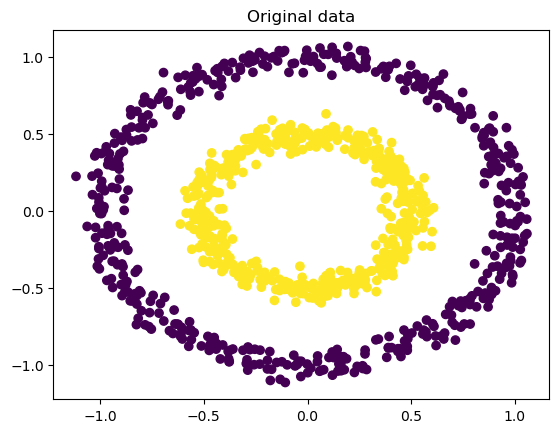

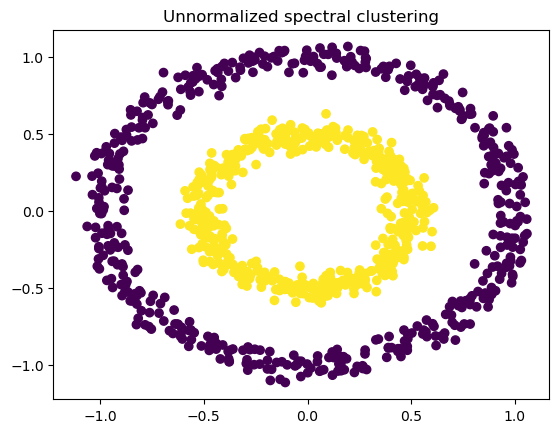

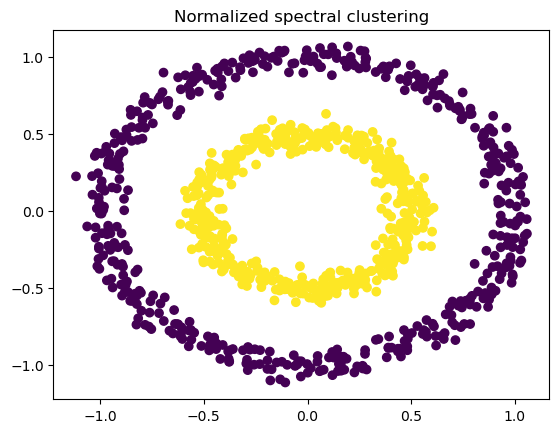

In [207]:
# example usage - circles
X, y = make_circles(n_samples=1000, factor=0.5, noise=0.05)

W_complete = rbf_kernel(X, gamma=20)
W = W_complete * (W_complete > 0.1)  

plt.scatter(X[:, 0], X[:, 1], c=y)
plt.title('Original data')
plt.show()

labels1 = spectral_clustering(W, 2, normalized=False)

plt.scatter(X[:, 0], X[:, 1], c=labels1)
plt.title('Unnormalized spectral clustering')
plt.show()

labels2 = spectral_clustering(W, 2, normalized=True)

plt.scatter(X[:, 0], X[:, 1], c=labels2)
plt.title('Normalized spectral clustering')
plt.show()

# Experiments

### D1 K=2

C:\Users\kubek\anaconda3\Lib\site-packages\networkx\drawing\nx_pylab.py:433: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  node_collection = ax.scatter(


<Figure size 600x600 with 0 Axes>

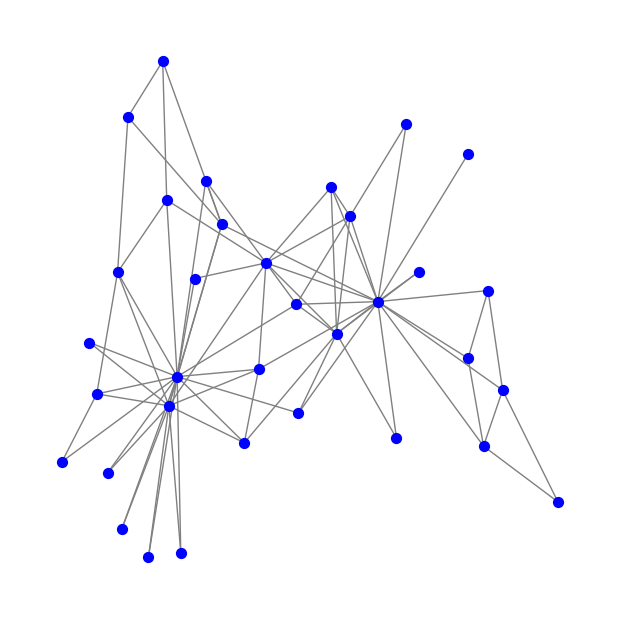

In [208]:
A = pd.read_csv("competition/D1-K=2.csv", header=None).values
G = nx.from_numpy_array(A)
plt.figure(figsize=(6, 6))

pos = nx.spring_layout(G)
draw_graph(G, pos)
plt.show()

<Figure size 600x600 with 0 Axes>

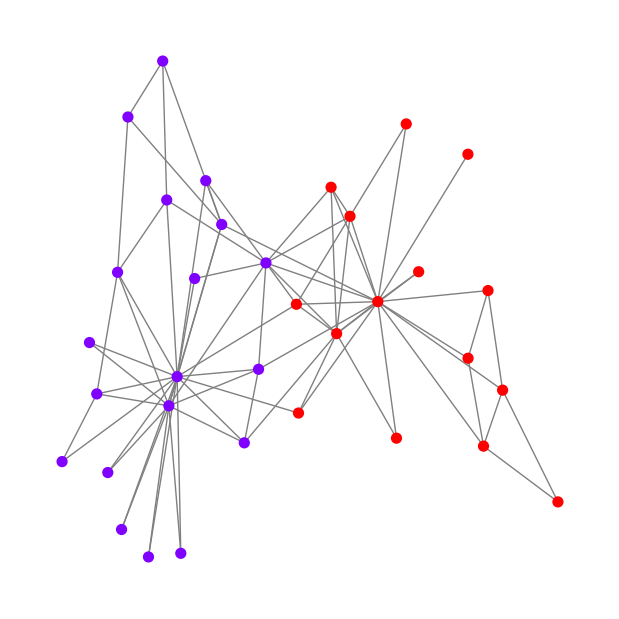

In [209]:
n_clusters = 2
labels = spectral_clustering(A, k=n_clusters, normalized=True)

plt.figure(figsize=(6, 6))
draw_graph(G, pos, labels)
plt.show()

In [210]:
save_labels(labels, "labels/D1-K=2.csv")

### D1-UNC

C:\Users\kubek\anaconda3\Lib\site-packages\networkx\drawing\nx_pylab.py:433: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  node_collection = ax.scatter(


<Figure size 600x600 with 0 Axes>

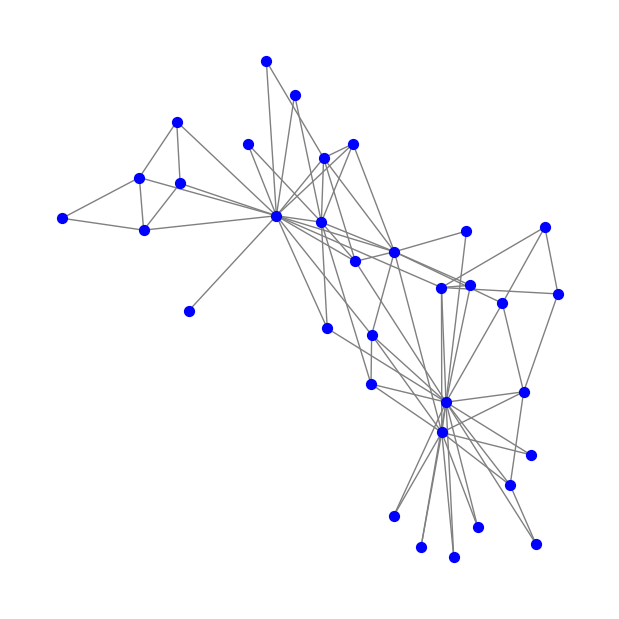

In [211]:
A = pd.read_csv("competition/D1-K=2.csv", header=None).values
G = nx.from_numpy_array(A)
plt.figure(figsize=(6, 6))
pos = nx.spring_layout(G)
draw_graph(G, pos)
plt.show()

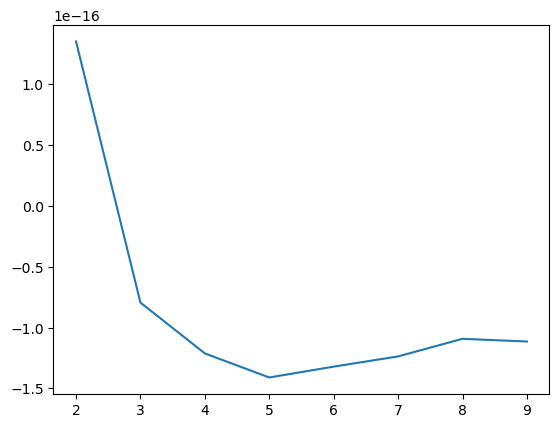

In [212]:
plt.plot(*compute_avg_silhouette_scores(A, repeat=100))
plt.show()

<Figure size 600x600 with 0 Axes>

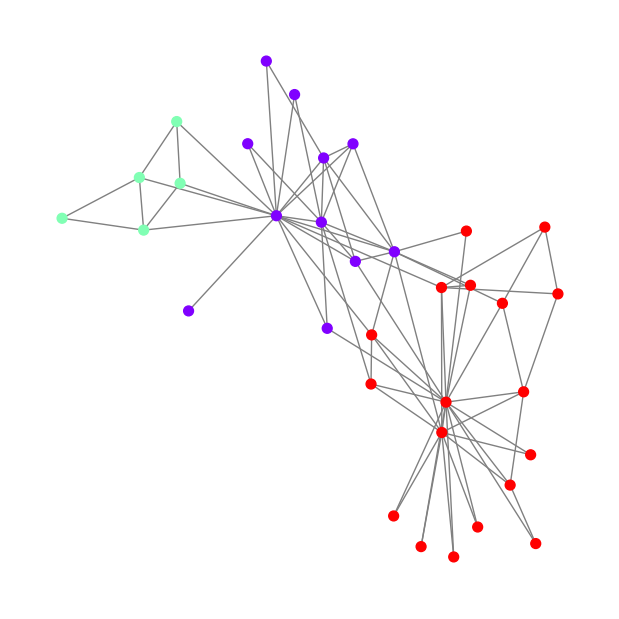

In [213]:
n_clusters = 3
labels = spectral_clustering(A, k=n_clusters, normalized=True)

plt.figure(figsize=(6, 6))
draw_graph(G, pos, labels)
plt.show()

In [214]:
save_labels(labels, "labels/D1-UNC.csv")

### D2 K=7

C:\Users\kubek\anaconda3\Lib\site-packages\networkx\drawing\nx_pylab.py:433: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  node_collection = ax.scatter(


<Figure size 600x600 with 0 Axes>

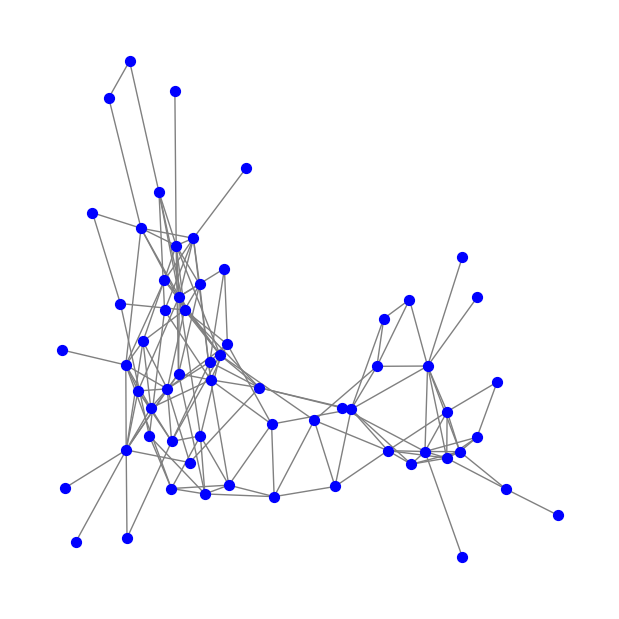

In [215]:
A = pd.read_csv("competition/D2-K=7.csv", header=None).values
G = nx.from_numpy_array(A)
plt.figure(figsize=(6, 6))
pos = nx.spring_layout(G)
draw_graph(G, pos)
plt.show()

<Figure size 600x600 with 0 Axes>

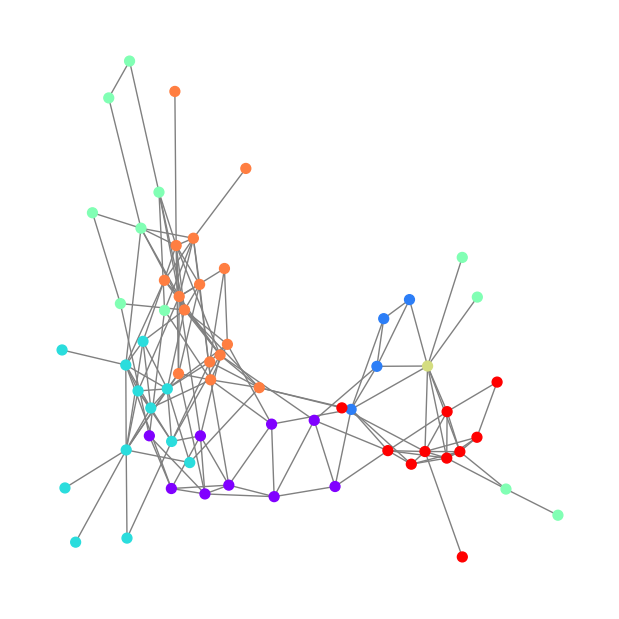

In [216]:
n_clusters = 7
labels = spectral_clustering(A, k=n_clusters, normalized=True)

plt.figure(figsize=(6, 6))
draw_graph(G, pos, labels)
plt.show()

In [217]:
save_labels(labels, "labels/D2-K=7.csv")

### D2-UNC

C:\Users\kubek\anaconda3\Lib\site-packages\networkx\drawing\nx_pylab.py:433: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  node_collection = ax.scatter(


<Figure size 600x600 with 0 Axes>

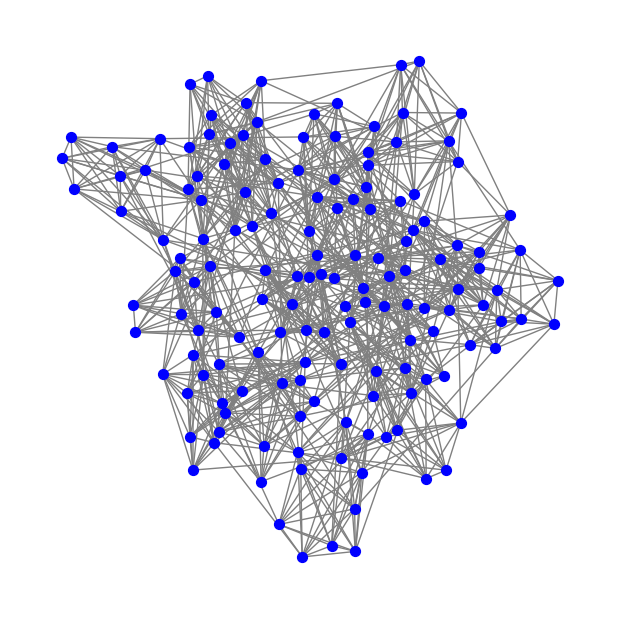

In [218]:
A = pd.read_csv("competition/D2-UNC.csv", header=None).values
G = nx.from_numpy_array(A)
plt.figure(figsize=(6, 6))
pos = nx.spring_layout(G)
draw_graph(G, pos)
plt.show()

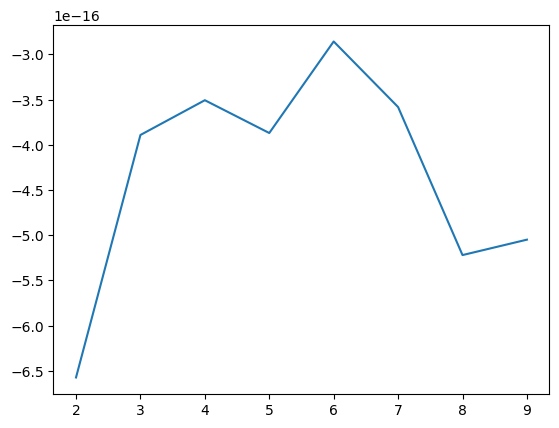

In [219]:
plt.plot(*compute_avg_silhouette_scores(A, repeat=100))
plt.show()

<Figure size 600x600 with 0 Axes>

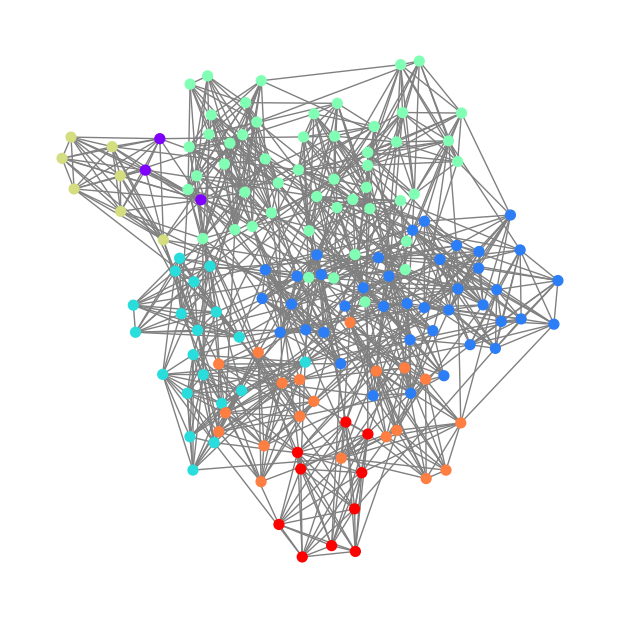

In [220]:
n_clusters = 7
labels = spectral_clustering(A, k=n_clusters, normalized=True)

plt.figure(figsize=(6, 6))
draw_graph(G, pos, labels)
plt.show()

In [221]:
save_labels(labels, "labels/D2-UNC.csv")

### D3 K=12

C:\Users\kubek\anaconda3\Lib\site-packages\networkx\drawing\nx_pylab.py:433: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  node_collection = ax.scatter(


<Figure size 600x600 with 0 Axes>

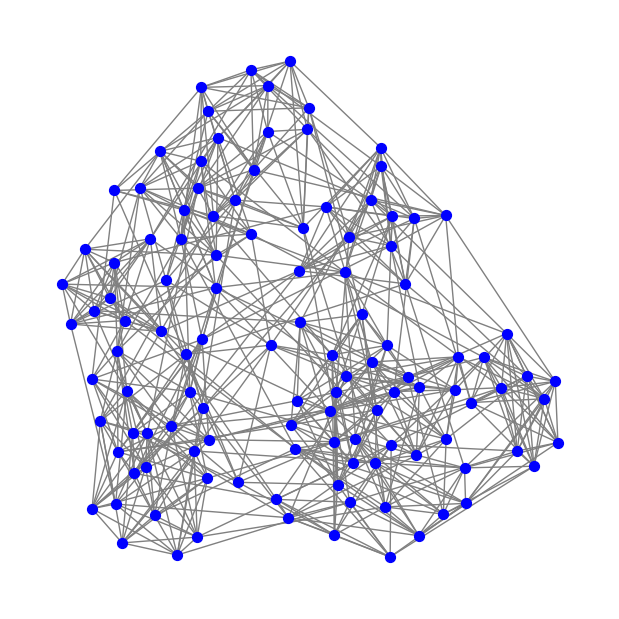

In [222]:
A = pd.read_csv("competition/D3-K=12.csv", header=None).values
G = nx.from_numpy_array(A)
plt.figure(figsize=(6, 6))
pos = nx.spring_layout(G)
draw_graph(G, pos)
plt.show()

<Figure size 600x600 with 0 Axes>

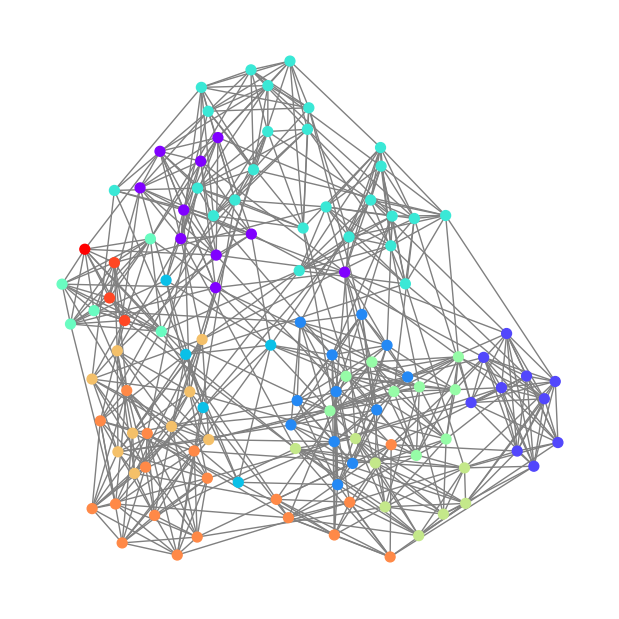

In [223]:
n_clusters = 12
labels = spectral_clustering(A, k=n_clusters, normalized=True)

plt.figure(figsize=(6, 6))
draw_graph(G, pos, labels)
plt.show()

In [224]:
save_labels(labels, "labels/D3-K=12.csv")

### D3-UNC

C:\Users\kubek\anaconda3\Lib\site-packages\networkx\drawing\nx_pylab.py:433: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  node_collection = ax.scatter(


<Figure size 600x600 with 0 Axes>

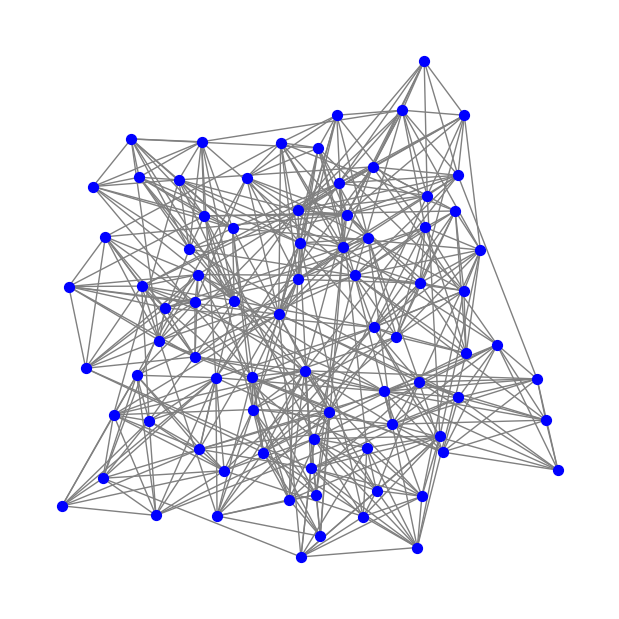

In [225]:
A = pd.read_csv("competition/D3-UNC.csv", header=None).values
G = nx.from_numpy_array(A)

plt.figure(figsize=(6, 6))
pos = nx.spring_layout(G)
draw_graph(G, pos)
plt.show()

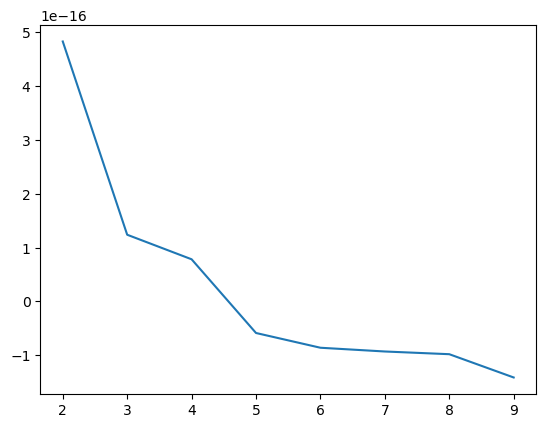

In [226]:
plt.plot(*compute_avg_silhouette_scores(A, repeat=100))
plt.show()

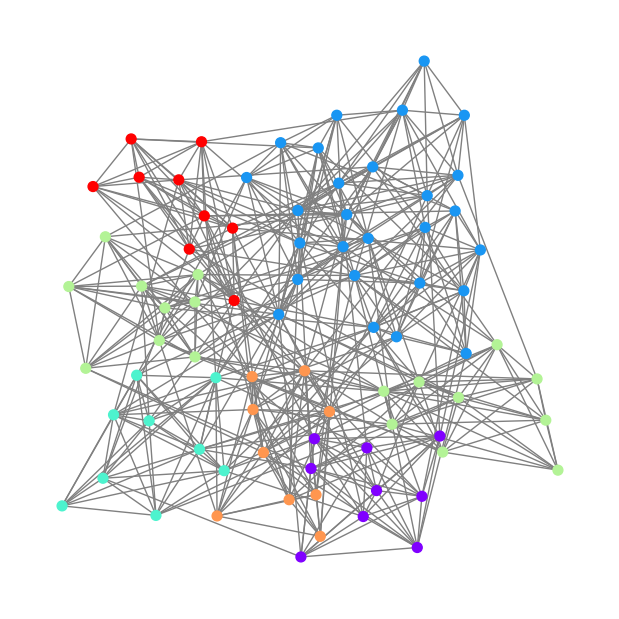

In [227]:
n_clusters = 6
labels = spectral_clustering(A, k=n_clusters, normalized=True)

plt.figure(figsize=(6, 6))
nx.draw(
    G, pos,
    with_labels=False,
    node_size=50,
    node_color=labels,
    cmap=plt.cm.rainbow,
    edge_color="gray"
)
plt.show()

In [228]:
save_labels(labels, "labels/D3-UNC.csv")